In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
df=pd.read_csv("/content/building_energy_data_extended.csv")

In [ ]:
print(df.head())
print(df.info())
print(df.shape)

             Timestamp Building_ID  Energy_Usage (kWh)  Temperature (°C)  \
0  2025-01-01 00:00:00        B001              121.30             -7.20   
1  2025-01-01 01:00:00        B001              230.76             12.62   
2  2025-01-01 02:00:00        B001              187.21             -1.33   
3  2025-01-01 03:00:00        B001              262.23              0.24   
4  2025-01-01 04:00:00        B001              472.97              5.44   

   Humidity (%) Building_Type Occupancy_Level  
0         79.36    Industrial             Low  
1         80.37    Industrial            High  
2         37.74    Industrial            High  
3         39.97    Industrial            High  
4         89.29    Industrial          Medium  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           7200 non-null   object 
 1

In [ ]:
print(df.isnull().sum())


Timestamp             0
Building_ID           0
Energy_Usage (kWh)    0
Temperature (°C)      0
Humidity (%)          0
Building_Type         0
Occupancy_Level       0
dtype: int64


In [ ]:

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df["hour"] = df["Timestamp"].dt.hour
df["day"] = df["Timestamp"].dt.dayofweek
df.head()

,Timestamp,Building_ID,Energy_Usage (kWh),Temperature (°C),Humidity (%),Building_Type,Occupancy_Level,hour,day
0,2025-01-01 00:00:00,B001,121.30,-7.20,79.36,Industrial,Low,0,2
1,2025-01-01 01:00:00,B001,230.76,12.62,80.37,Industrial,High,1,2
2,2025-01-01 02:00:00,B001,187.21,-1.33,37.74,Industrial,High,2,2
3,2025-01-01 03:00:00,B001,262.23,0.24,39.97,Industrial,High,3,2
4,2025-01-01 04:00:00,B001,472.97,5.44,89.29,Industrial,Medium,4,2


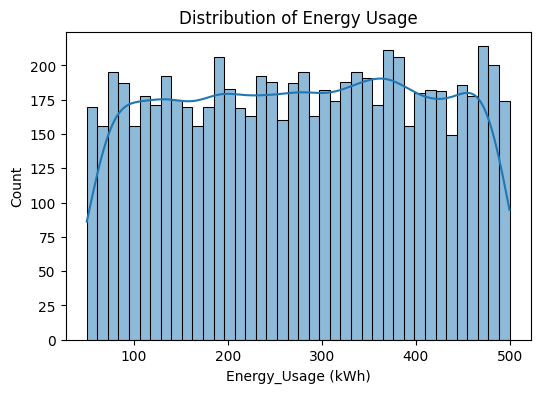

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Energy_Usage (kWh)'], bins=40, kde=True)
plt.title("Distribution of Energy Usage")
plt.show()

In [ ]:

df.head()


,Timestamp,Building_ID,Energy_Usage (kWh),Temperature (°C),Humidity (%),Building_Type,Occupancy_Level,hour,day
0,2025-01-01 00:00:00,B001,121.30,-7.20,79.36,Industrial,Low,0,2
1,2025-01-01 01:00:00,B001,230.76,12.62,80.37,Industrial,High,1,2
2,2025-01-01 02:00:00,B001,187.21,-1.33,37.74,Industrial,High,2,2
3,2025-01-01 03:00:00,B001,262.23,0.24,39.97,Industrial,High,3,2
4,2025-01-01 04:00:00,B001,472.97,5.44,89.29,Industrial,Medium,4,2


In [ ]:
feature_df = df.groupby("Building_ID").agg(
    Peak_Demand=("Energy_Usage (kWh)", "max"),
    Avg_Load=("Energy_Usage (kWh)", "mean"),
    Load_Variability=("Energy_Usage (kWh)", "std"),
    Night_Load=("Energy_Usage (kWh)", lambda x: x[df.loc[x.index, "hour"].between(0,5)].mean()),
    Day_Load=("Energy_Usage (kWh)", lambda x: x[df.loc[x.index, "hour"].between(9,18)].mean()),
    Weekend_Load=("Energy_Usage (kWh)", lambda x: x[df.loc[x.index, "day"] >= 5].mean())
).reset_index()
feature_df.head()

,Building_ID,Peak_Demand,Avg_Load,Load_Variability,Night_Load,Day_Load,Weekend_Load
0,B001,499.70,265.447083,130.946407,248.924556,275.798133,260.965208
1,B002,498.84,285.201444,125.645932,287.790222,295.835000,311.717812
2,B003,499.87,272.299833,128.504307,278.742556,248.572267,257.812604
3,B004,495.67,269.566056,129.018343,267.005333,272.358733,250.391875
4,B005,499.85,274.829278,125.785488,265.543111,286.760600,268.514167


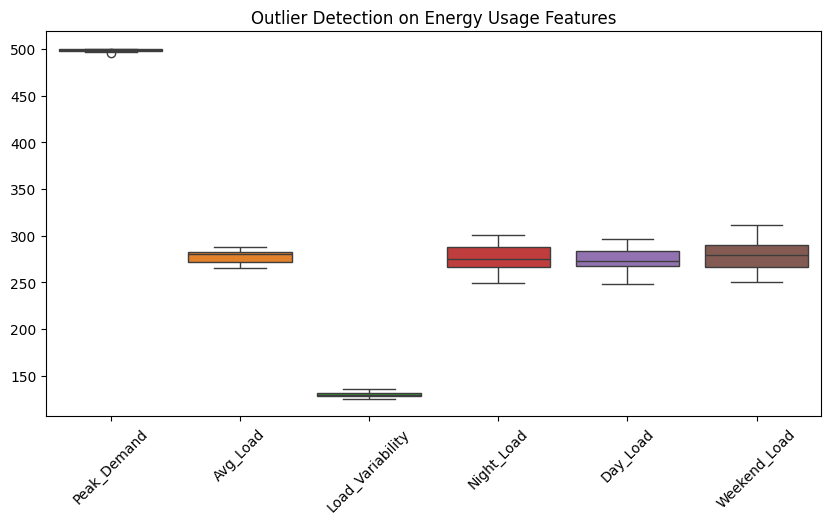

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=feature_df.drop("Building_ID", axis=1))
plt.xticks(rotation=45)
plt.title("Outlier Detection on Energy Usage Features")
plt.show()

In [ ]:
numeric_features = feature_df.drop("Building_ID", axis=1)

Q1 = numeric_features.quantile(0.25)
Q3 = numeric_features.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_features < (Q1 - 1.5 * IQR)) |
            (numeric_features > (Q3 + 1.5 * IQR)))

outliers.sum()

,0
Peak_Demand,1
Avg_Load,0
Load_Variability,0
Night_Load,0
Day_Load,0
Weekend_Load,0


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(
    feature_df.drop("Building_ID", axis=1)
)

NameError: name 'StandardScaler' is not defined

In [ ]:
pca = PCA()
pca.fit(scaled_data)


PCA()

In [ ]:
pca_full = PCA()
pca_full.fit(scaled_data)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for i, var in enumerate(cumulative_var):
    print(f"PC{i+1}: {var:.2f}")

PC1: 0.37
PC2: 0.63
PC3: 0.80
PC4: 0.94
PC5: 0.98
PC6: 1.00


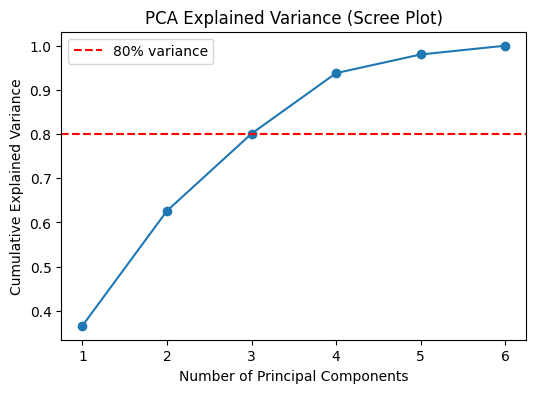

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance (Scree Plot)")
plt.legend()
plt.show()

In [ ]:
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_data)


In [ ]:
feature_names = feature_df.drop("Building_ID", axis=1).columns

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=feature_names
)

loadings

,PC1,PC2,PC3
Peak_Demand,-0.157432,-0.170327,0.752810
Avg_Load,0.617992,-0.202572,0.132570
Load_Variability,-0.032098,-0.496727,0.438586
Night_Load,0.294073,-0.565223,-0.382812
Day_Load,0.356536,0.600489,0.249433
Weekend_Load,0.615365,0.056146,0.120757


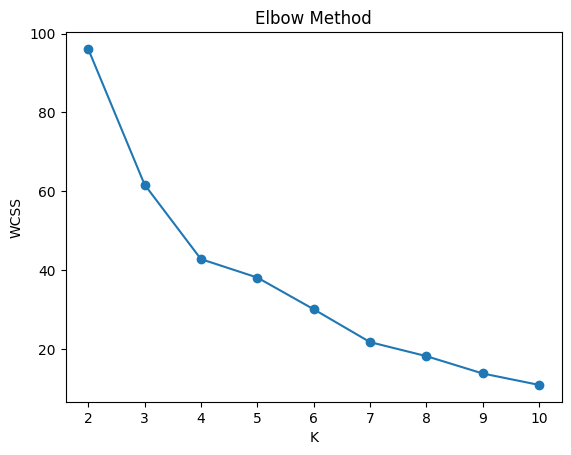

In [ ]:
wcss = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [ ]:
for k in range(2,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    print(f"K={k} → Silhouette Score = {score:.3f}")


K=2 → Silhouette Score = 0.299
K=3 → Silhouette Score = 0.285
K=4 → Silhouette Score = 0.205
K=5 → Silhouette Score = 0.223
K=6 → Silhouette Score = 0.246
K=7 → Silhouette Score = 0.217


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(pca_data)
# pca_df["Cluster"] = labels

In [ ]:
clustered_df = feature_df.copy()
clustered_df["Cluster"] = labels

clustered_df.head()

,Building_ID,Peak_Demand,Avg_Load,Load_Variability,Night_Load,Day_Load,Weekend_Load,Cluster
0,B001,499.70,265.447083,130.946407,248.924556,275.798133,260.965208,2
1,B002,498.84,285.201444,125.645932,287.790222,295.835000,311.717812,1
2,B003,499.87,272.299833,128.504307,278.742556,248.572267,257.812604,2
3,B004,495.67,269.566056,129.018343,267.005333,272.358733,250.391875,2
4,B005,499.85,274.829278,125.785488,265.543111,286.760600,268.514167,2


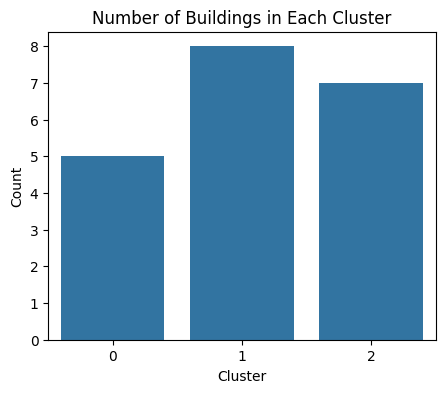

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x="Cluster", data=clustered_df)
plt.title("Number of Buildings in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

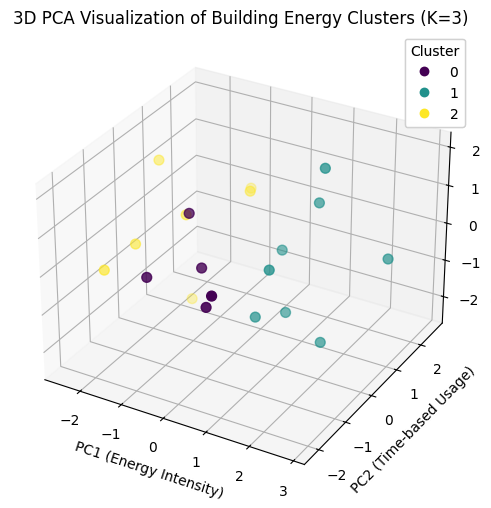

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_data[:, 0],   # PC1
    pca_data[:, 1],   # PC2
    pca_data[:, 2],   # PC3
    c=labels,
    cmap='viridis',
    s=50
)

ax.set_xlabel("PC1 (Energy Intensity)")
ax.set_ylabel("PC2 (Time-based Usage)")
ax.set_zlabel("PC3 (Peak & Variability)")

ax.set_title("3D PCA Visualization of Building Energy Clusters (K=3)")

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()


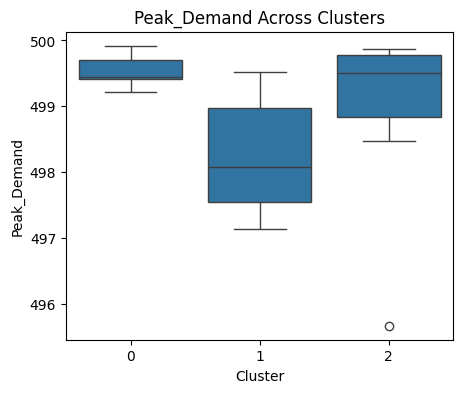

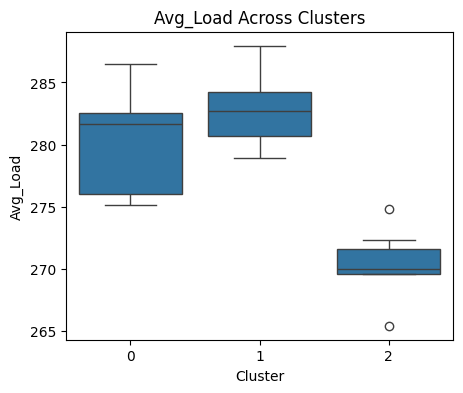

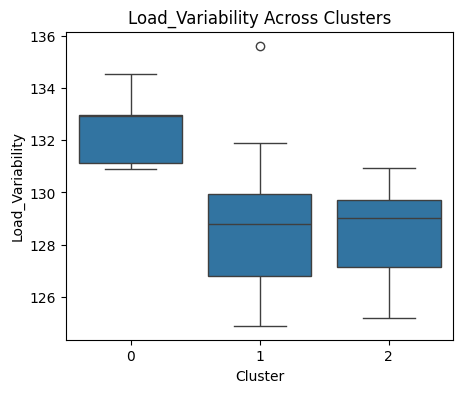

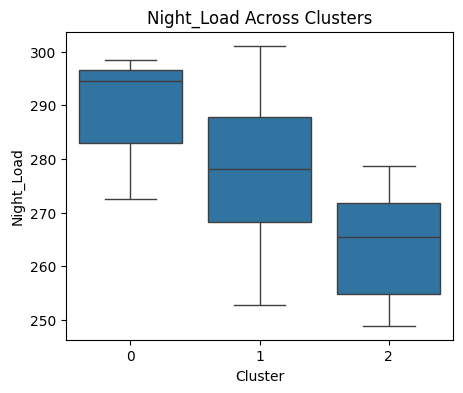

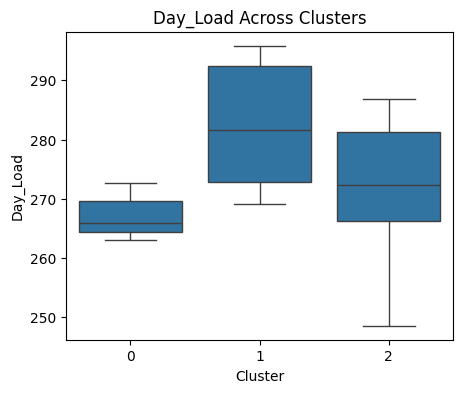

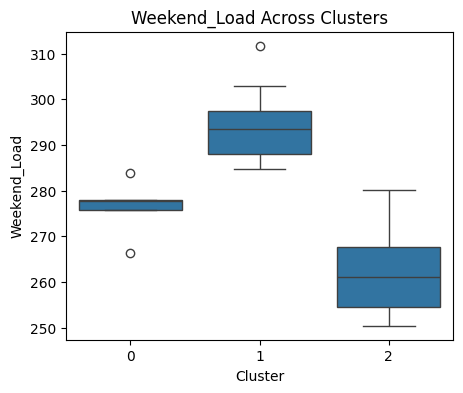

In [ ]:
features = [
    "Peak_Demand", "Avg_Load", "Load_Variability",
    "Night_Load", "Day_Load", "Weekend_Load"
]

for col in features:
    plt.figure(figsize=(5,4))
    sns.boxplot(x="Cluster", y=col, data=clustered_df)
    plt.title(f"{col} Across Clusters")
    plt.show()

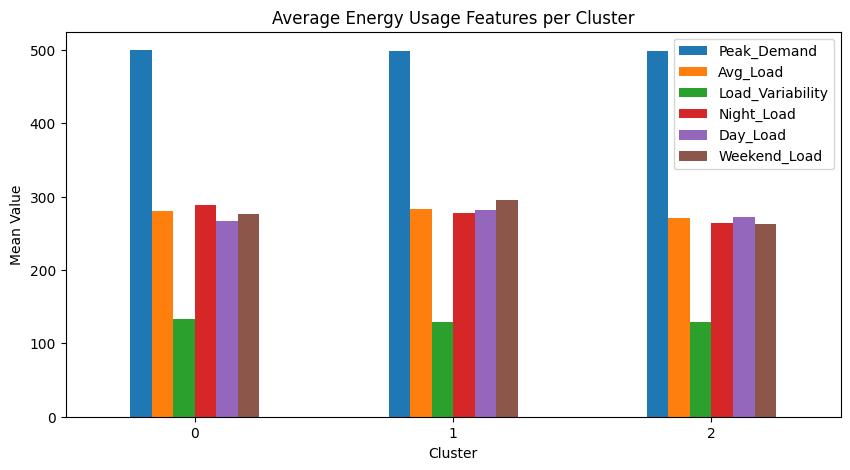

In [ ]:
cluster_means = clustered_df.groupby("Cluster").mean(numeric_only=True)

cluster_means.plot(kind="bar", figsize=(10,5))
plt.title("Average Energy Usage Features per Cluster")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.show()

In [ ]:
cluster_means

,Peak_Demand,Avg_Load,Load_Variability,Night_Load,Day_Load,Weekend_Load
Cluster,,,,,,
0,499.542000,280.362522,132.499228,289.007244,267.121880,276.303562
1,498.235000,282.855250,129.007221,277.721069,282.209825,294.670091
2,498.895714,270.389623,128.414995,263.806413,271.791371,262.235774


In [ ]:
cluster_labels = {
    0: "Night-Heavy & Variable Buildings",
    1: "High-Usage Daytime & Weekend Buildings",
    2: "Energy-Efficient & Stable Buildings"
}

clustered_df["Cluster_Label"] = clustered_df["Cluster"].map(cluster_labels)

clustered_df[["Cluster", "Cluster_Label"]].head()


,Cluster,Cluster_Label
0,2,Energy-Efficient & Stable Buildings
1,1,High-Usage Daytime & Weekend Buildings
2,2,Energy-Efficient & Stable Buildings
3,2,Energy-Efficient & Stable Buildings
4,2,Energy-Efficient & Stable Buildings


In [ ]:
cluster_recommendations = {
    0: [
        "Implement automated night-time shutdown of non-essential systems",
        "Use smart timers and occupancy sensors",
        "Apply load smoothing using energy storage",
        "Detect and eliminate abnormal night-time energy spikes"
    ],

    1: [
        "Optimize HVAC systems during peak working hours",
        "Improve daylight utilization to reduce lighting load",
        "Enroll buildings in demand response programs",
        "Optimize weekend operational schedules"
    ],

    2: [
        "Use as benchmark buildings for best practices",
        "Maintain current energy-efficient systems",
        "Apply fine-grained monitoring for further optimization",
        "Integrate renewable energy sources like solar panels"
    ]
}

In [ ]:
clustered_df["Recommendations"] = clustered_df["Cluster"].map(cluster_recommendations)

clustered_df[["Cluster_Label", "Recommendations"]].head()

,Cluster_Label,Recommendations
0,Energy-Efficient & Stable Buildings,[Use as benchmark buildings for best practices...
1,High-Usage Daytime & Weekend Buildings,[Optimize HVAC systems during peak working hou...
2,Energy-Efficient & Stable Buildings,[Use as benchmark buildings for best practices...
3,Energy-Efficient & Stable Buildings,[Use as benchmark buildings for best practices...
4,Energy-Efficient & Stable Buildings,[Use as benchmark buildings for best practices...


In [ ]:
recommendation_df = pd.DataFrame({
    "Cluster": cluster_recommendations.keys(),
    "Cluster_Label": [cluster_labels[k] for k in cluster_recommendations.keys()],
    "Recommended_Actions": cluster_recommendations.values()
})

recommendation_df

,Cluster,Cluster_Label,Recommended_Actions
0,0,Night-Heavy & Variable Buildings,[Implement automated night-time shutdown of no...
1,1,High-Usage Daytime & Weekend Buildings,[Optimize HVAC systems during peak working hou...
2,2,Energy-Efficient & Stable Buildings,[Use as benchmark buildings for best practices...


In [ ]:
clustered_df.sample(14)

,Building_ID,Peak_Demand,Avg_Load,Load_Variability,Night_Load,Day_Load,Weekend_Load,Cluster,Cluster_Label,Recommendations
17,B018,498.48,269.977083,125.197052,249.198222,286.609600,266.756458,2,Energy-Efficient & Stable Buildings,[Use as benchmark buildings for best practices...
3,B004,495.67,269.566056,129.018343,267.005333,272.358733,250.391875,2,Energy-Efficient & Stable Buildings,[Use as benchmark buildings for best practices...
7,B008,499.21,286.487139,134.564272,296.636222,269.624733,278.003333,0,Night-Heavy & Variable Buildings,[Implement automated night-time shutdown of no...
11,B012,498.10,278.919583,128.754548,270.193222,281.401333,287.444792,1,High-Usage Daytime & Weekend Buildings,[Optimize HVAC systems during peak working hou...
8,B009,499.39,283.929361,128.808764,268.851444,293.365800,288.207187,1,High-Usage Daytime & Weekend Buildings,[Optimize HVAC systems during peak working hou...
10,B011,499.71,275.997750,132.932858,294.598667,264.341867,266.425000,0,Night-Heavy & Variable Buildings,[Implement automated night-time shutdown of no...
2,B003,499.87,272.299833,128.504307,278.742556,248.572267,257.812604,2,Energy-Efficient & Stable Buildings,[Use as benchmark buildings for best practices...
14,B015,497.15,283.566056,127.159361,301.096889,281.832067,293.311458,1,High-Usage Daytime & Weekend Buildings,[Optimize HVAC systems during peak working hou...
12,B013,499.45,281.653083,130.904763,282.898444,265.930867,275.660000,0,Night-Heavy & Variable Buildings,[Implement automated night-time shutdown of no...
9,B010,497.68,281.878694,129.287852,288.230222,270.267533,284.660521,1,High-Usage Daytime & Weekend Buildings,[Optimize HVAC systems during peak working hou...
